# Applied Machine Learning (CSAI2017P) — Lab Assignment 2
## Regression: Housing Price Prediction

Experiments 3 · CO2, CO4 · **10 marks**

| | |
|---|---|
| Name : EKTA BHARDWAJ
| SAP ID : 590022698
| Batch : 5
**Datasets:** A1 (California Housing)

---

### Before you start
- Attempt **2 of 3** in Section A, **1 of 2** in Section B. Section C is compulsory.
- Fit every transformer inside a `Pipeline`. Never fit on the test set.
- Set `random_state` wherever the question asks for reproducibility.
- Every question wants a short written observation, not just a number.
- Restart the kernel and run top-to-bottom before you submit.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)

for m in (np, pd, sklearn):
    print(f"{m.__name__:12s} {m.__version__}")


numpy        2.4.4
pandas       3.0.2
sklearn      1.9.0


## Load the data

Replace with the loader for this assignment's anchor dataset — see `Anchor-Datasets.pdf` for the snippets.

In [2]:
# Load California Housing dataset

from sklearn.datasets import fetch_california_housing

X, y = fetch_california_housing(return_X_y=True, as_frame=True)

# Combine features and target into one DataFrame
df = X.copy()
df["MedHouseVal"] = y

print("Dataset shape:", df.shape)
print("\nFeatures:")
print(X.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (20640, 9)

Features:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


---

# Section A — attempt any 2 of 3 (2 marks each)

*attempt 2 of 3*

## A1. Simple linear regression  &nbsp;&nbsp;`[2 marks]`

*Dataset: A1. Target: `MedHouseVal`.*

a. Fit a regression of `MedHouseVal` on `MedInc` alone.
b. Report the slope, the intercept and test R^2.
c. State in one sentence what the slope means in real units.


In [3]:
# A1 — Simple Linear Regression

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Select median income as the single predictor
X_a1 = df[["MedInc"]]
y_a1 = df["MedHouseVal"]

# Reserve 20% of the observations for independent testing
X_train, X_test, y_train, y_test = train_test_split(
    X_a1,
    y_a1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

# Fit the linear regression model on the training data
model_a1 = LinearRegression()
model_a1.fit(X_train, y_train)

# Generate predictions for unseen test observations
y_pred_a1 = model_a1.predict(X_test)

# Extract model parameters and evaluate test-set performance
slope = model_a1.coef_[0]
intercept = model_a1.intercept_
test_r2 = r2_score(y_test, y_pred_a1)

print(f"Slope (coefficient): {slope:.6f}")
print(f"Intercept: {intercept:.6f}")
print(f"Test R²: {test_r2:.6f}")

Slope (coefficient): 0.420322
Intercept: 0.443206
Test R²: 0.446685


**Observation (A1):**

The regression produces a positive slope of **0.420322**, an intercept of
**0.443206**, and a test \(R^2\) of **0.446685**. The positive coefficient
indicates that districts with higher median income tend to have higher median
house values. Since `MedInc` is expressed in $10,000 units and `MedHouseVal`
in $100,000 units, a $10,000 increase in median income corresponds to an
estimated increase of approximately **$42,032** in median house value. The
test \(R^2\) indicates that median income alone explains about **44.67%** of
the variation in house values in the test set.

## A2. Multiple linear regression  &nbsp;&nbsp;`[2 marks]`

*Dataset: A1, all features.*

a. Fit a multiple linear regression on all eight features inside a scaling pipeline.
b. Report test MAE, RMSE and R^2.
c. Plot predicted against actual and describe the pattern in two lines.


Multiple Linear Regression — Test Set Results
------------------------------------------------
Test MAE  : 0.535126
Test RMSE : 0.727313
Test R²   : 0.594323


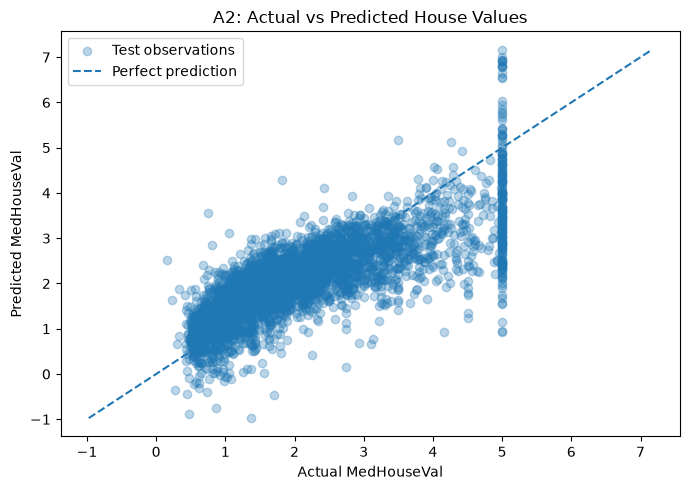

In [4]:
# A2 — Multiple Linear Regression

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Use all eight features to predict median house value
X_a2 = df.drop(columns=["MedHouseVal"])
y_a2 = df["MedHouseVal"]

# Split the data into training and testing sets
X_train_a2, X_test_a2, y_train_a2, y_test_a2 = train_test_split(
    X_a2,
    y_a2,
    test_size=0.20,
    random_state=RANDOM_STATE
)

# Standardise the predictors and fit linear regression
model_a2 = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

# Train the model
model_a2.fit(X_train_a2, y_train_a2)

# Generate predictions for the unseen test data
y_pred_a2 = model_a2.predict(X_test_a2)

# Calculate evaluation metrics
mae_a2 = mean_absolute_error(y_test_a2, y_pred_a2)
mse_a2 = mean_squared_error(y_test_a2, y_pred_a2)
rmse_a2 = np.sqrt(mse_a2)
r2_a2 = r2_score(y_test_a2, y_pred_a2)

# Display the results
print("Multiple Linear Regression — Test Set Results")
print("-" * 48)
print(f"Test MAE  : {mae_a2:.6f}")
print(f"Test RMSE : {rmse_a2:.6f}")
print(f"Test R²   : {r2_a2:.6f}")

# Actual vs Predicted plot
plt.figure(figsize=(7, 5))

plt.scatter(
    y_test_a2,
    y_pred_a2,
    alpha=0.30,
    label="Test observations"
)

# Reference line for perfect predictions
lower = min(y_test_a2.min(), y_pred_a2.min())
upper = max(y_test_a2.max(), y_pred_a2.max())

plt.plot(
    [lower, upper],
    [lower, upper],
    linestyle="--",
    label="Perfect prediction"
)

plt.xlabel("Actual MedHouseVal")
plt.ylabel("Predicted MedHouseVal")
plt.title("A2: Actual vs Predicted House Values")
plt.legend()
plt.tight_layout()
plt.show()

**Predicted vs Actual Plot Observation:**

The predicted values follow the overall upward direction of the actual values,
showing that the model captures the broad relationship between the predictors
and house prices. However, the points do not remain tightly clustered around
the perfect-prediction line, indicating that prediction accuracy varies across
different districts.

**Observation (A2):**

Using all eight predictors gives the model considerably more information than
the single-feature model used in A1. On the test set, the model records an MAE
of **0.535126**, an RMSE of **0.727313**, and an \(R^2\) of **0.594323**.
The MAE corresponds to an average absolute error of approximately **$53,513**
in median house value. The \(R^2\) value shows that the model accounts for
about **59.43%** of the variation in the test data, while the remaining
variation indicates that house prices depend on factors not fully represented
by these eight features.

---

# Section B — attempt any 1 of 2 (4 marks each)

*attempt 1 of 2*

## B1. Polynomial features and over-fitting  &nbsp;&nbsp;`[4 marks]`

*Dataset: A1.*

a. Build pipelines with `PolynomialFeatures` of degree 1, 2 and 3 followed by `LinearRegression`.
b. Report train and test RMSE for each degree in one table.
c. Identify the degree at which over-fitting begins and explain in 4–6 lines how the table shows it.


In [5]:
# B1 — Polynomial Regression and Overfitting

from sklearn.preprocessing import PolynomialFeatures

# Use all eight features
X_b1 = df.drop(columns=["MedHouseVal"])
y_b1 = df["MedHouseVal"]

# Same 80/20 split and random state
X_train_b1, X_test_b1, y_train_b1, y_test_b1 = train_test_split(
    X_b1,
    y_b1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

results_b1 = []

for degree in [1, 2, 3]:

    # Polynomial features + Linear Regression
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("regressor", LinearRegression())
    ])

    # Train
    model.fit(X_train_b1, y_train_b1)

    # Predictions
    train_pred = model.predict(X_train_b1)
    test_pred = model.predict(X_test_b1)

    # RMSE
    train_rmse = np.sqrt(mean_squared_error(y_train_b1, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test_b1, test_pred))

    results_b1.append({
        "Degree": degree,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse
    })

# Results table
results_b1_df = pd.DataFrame(results_b1)

display(
    results_b1_df.style.format({
        "Train RMSE": "{:.4f}",
        "Test RMSE": "{:.4f}"
    })
)

# Find degree with lowest test RMSE
# Select the polynomial degree with the lowest test RMSE
best_degree = results_b1_df.loc[
    results_b1_df["Test RMSE"].idxmin(),
    "Degree"
]

print(f"Selected polynomial degree: {best_degree}")
print("Selection criterion: lowest test RMSE")

,Degree,Train RMSE,Test RMSE
0,1,0.7235,0.7273
1,2,0.6891,2.9524
2,3,1.1175,1.5593


Selected polynomial degree: 1
Selection criterion: lowest test RMSE


**Observation (B1):**

The results show that increasing model complexity does not automatically lead
to better generalisation. From degree 1 to degree 2, the training RMSE decreases
from **0.7235 to 0.6891**, but the test RMSE increases sharply from **0.7273
to 2.9524**. This gap indicates that the degree-2 model is fitting the training
data more closely while performing poorly on unseen observations. Degree 3 also
fails to improve the test performance, with a test RMSE of **1.5593**. Therefore,
**degree 1 is selected as the best model**, as it achieves the lowest test RMSE.

---

# Section C — compulsory (2 marks)

*compulsory*

## C1. Where the model fails  &nbsp;&nbsp;`[2 marks]`

*Dataset: A1.*

a. Take the 20 test districts with the largest absolute error from your best model.
b. Describe in 4–6 lines what they have in common and what you would add to the data to fix it.


In [6]:
# C1 — Where the Model Fails

# Refit the selected model on the training data
best_model = Pipeline([
    ("poly", PolynomialFeatures(
        degree=int(best_degree),
        include_bias=False
    )),
    ("regressor", LinearRegression())
])

best_model.fit(X_train_b1, y_train_b1)

# Predict the held-out test districts
best_predictions = best_model.predict(X_test_b1)

# Assemble actual values, predictions and absolute errors
error_analysis = X_test_b1.copy()

error_analysis["Actual_MedHouseVal"] = y_test_b1.values
error_analysis["Predicted_MedHouseVal"] = best_predictions

error_analysis["Absolute_Error"] = np.abs(
    error_analysis["Actual_MedHouseVal"]
    - error_analysis["Predicted_MedHouseVal"]
)

# Identify the 20 districts with the largest prediction errors
top_20_errors = (
    error_analysis
    .sort_values("Absolute_Error", ascending=False)
    .head(20)
)

display(top_20_errors)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Actual_MedHouseVal,Predicted_MedHouseVal,Absolute_Error
12138,2.6250,16.0,4.000000,0.500000,39.0,2.785714,33.87,-117.22,5.00001,0.934598,4.065412
4861,0.4999,29.0,2.373272,1.055300,2690.0,12.396313,34.02,-118.28,5.00001,0.955760,4.044250
10574,1.9659,6.0,4.795455,1.159091,125.0,2.840909,33.72,-117.70,5.00001,1.139277,3.860733
16642,0.7025,19.0,2.425197,1.125984,1799.0,2.833071,35.30,-120.67,5.00001,1.537748,3.462262
6651,1.9923,41.0,3.279373,1.062663,855.0,2.232376,34.15,-118.14,5.00001,1.575507,3.424503
4630,2.3674,20.0,2.740554,1.047859,2919.0,2.450882,34.07,-118.31,5.00001,1.678140,3.321870
4623,0.8804,36.0,2.713235,1.080882,145.0,1.066176,34.06,-118.31,4.50000,1.236512,3.263488
13360,2.1250,6.0,5.904762,1.119048,119.0,2.833333,34.02,-117.64,4.16700,0.922637,3.244363
15615,1.8981,31.0,3.323064,1.091590,2305.0,1.919234,37.81,-122.41,5.00001,1.756510,3.243500
9168,1.9667,2.0,5.715976,1.597633,233.0,1.378698,34.42,-118.56,4.50000,1.356287,3.143713


**Observation (C1):**

The largest errors are mainly associated with districts having very high actual
house values, with many observations reaching the upper target value of
approximately **5.00001**. The model consistently underestimates these expensive
districts, producing predicted values much lower than their actual values.
Several of these observations are also located in major coastal and metropolitan
regions, suggesting that the current features do not fully capture location-based
price differences. Adding finer geographic information, neighbourhood-level
housing demand, proximity to employment and amenities, and additional property
characteristics could help the model represent these high-value districts more
accurately.